<table>
<tr><td><img style="height: 150px;" src="images/geo_hydro1.jpg"></td>
<td bgcolor="#FFFFFF">
    <p style="font-size: xx-large; font-weight: 900; line-height: 100%">pySTALAGMITE</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);"><b style=color:red;>STALAGMITE</b> modelling</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);">Georg Kaufmann</p>
    </td>
<td><img style="height: 150px;" src="images/pySTALAGMITE.png"></td>
</tr>
</table>

----
# `pySTALAGMITE`

pySTALAGMITE, a program package prediction the shape of a stalagmite from pre-defined climate conditions.

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import sys

import libCHEM,libSTALAGMITE

----
# Climatic control
In this notebook, we discuss a simple climate driver for the growth of stalagmites.

The growth of stalagmites is controlled by **climate conditions**.
The main controlling parameter values are:
- **temperature:** Both the surface and the cave temperature are relevant.
- **precipitation:** controls the amount of water arriving in the cave as droplets.
- **CO$_2$ partial pressure:** controls via the soil the amount of calcite dissolved, and via cave atmosphere the calcium equilibrium.

As shown below, climate conditions between **glacial** and **interglacial** stages are different.
- Interglacial conditions favour precipitation (e.g. speleothem growth)
- Glacial conditions favor dissolution (e.g. solution pockets)

<img src='images/Kempe_scheme_stages.jpg'>

---
## Climate driver
We create a simple climate driver by defining climate values for glacial and interglacial conditions for
- Surface temperature, $T_{surf}$, `TSurf`
- Soil temperature, $T_{soil}$, `TSoil`
- Cave temperature, $T_{cave}$, `TCave`
- Atmospheric carbon-dioxide pressure, $P_{atm}$, `PAtm`
- Soil carbon-dioxide pressure, $P_{soil}$, `PSoil`
- Cave carbon-dioxide pressure, $P_{cave}$, `PCave`
- Cave drip interval, $D_{cave}$, `dropCave`

Usually, we read these parameter values in with the 
functions `readParameter2D` and `createTime2D` to run the climate driver `setClimate2D` ...

----
## `setClimate2D()`

In [3]:
help(libSTALAGMITE.setClimate2D)

Help on function setClimate2D in module libSTALAGMITE:

setClimate2D(time, timeStart, timeEnd, TSoilmin, TSoilmax, PSoilmin, PSoilmax, TCavemin, TCavemax, PCavemin, PCavemax, DCavemin, DCavemax, rawTimeline=array([[-999, -999],
       [-999, -999]]), climate='simple')
    ! function sets climate conditions for a given time
    ! input:
    !  time,timeStart,timeEnd [a]     : current time, time limits
    !  TSoilmin,TSoilmax [C]          : Soil temperature (min/max)
    !  PSoilmin,PSoilmax [ppm]        : Soil CO2 (min/max)
    !  TCavemin,TCavemax [C]          : Cave temperature (min/max)
    !  PCavemin,PCavemax [ppm]        : Cave CO2 (min/max)
    !  DCavemin,DCavemax [s]          : Cave drip interval (min/max)
    !  rawTimeline                    : times and soil temperature from file
    !  climate                        : flag for climate type
    ! output:
    !  TSoil     : Soil temperature
    !  PSoil     : Soil CO2
    !  TCave     : Cave temperature
    !  PCave     : Cav

In [4]:
def plotClimate(iSaved,data,climate):
    """
    plot climate parameter as function of time
    """
    plt.figure(figsize=(12,6))
    plt.title('Climate variation ('+climate+')')
    plt.xlim([timeStart,timeEnd])
    plt.xlabel('Time [BP]')
    plt.ylim([1e-2,1e5])
    plt.yscale('log')

    plt.plot(data[0,0:iSaved],data[1,0:iSaved],lw=5,color=(0,0,1),label='TSoil [$^{\circ}$C]')
    plt.plot(data[0,0:iSaved],data[2,0:iSaved],lw=2,color=(0,0.5,1),label='TCave [$^{\circ}$C]')

    plt.plot(data[0,0:iSaved],data[3,0:iSaved],lw=5,color=(1,0,0),label='PSoil [ppm]')
    plt.plot(data[0,0:iSaved],data[4,0:iSaved],lw=2,color=(1,0.5,0),label='PCave [ppm]')

    plt.plot(data[0,0:iSaved],data[5,0:iSaved],lw=2,color=(1,0.5,1),label='DCave [s]')
    #plt.plot(data[0,:],data[1,:],lw=2,color=(0,0,1),label='tempsoil [$^{\circ}$C]')
    plt.grid()
    plt.legend()
    return

... in this notebook, we define the parameter values manually in a cell:

----
## Simple climate driver

In [5]:
PAtmmin,PAtmmax   = 400.0,    400.0
TSoilmin,TSoilmax = 10.0,      10.0
PSoilmin,PSoilmax = 400.0,  40000.0
TCavemin,TCavemax = 10.0,      10.0
PCavemin,PCavemax = 400.0,    400.0
DCavemin,DCavemax = 1000.0,     1.0

timeStep          = 10.
timeStart,timeEnd,rawTimeline = libSTALAGMITE.readTimeline2D(path='div/run_simple1/',control=True)

climate='simple'

        timeStart,timeEnd [a]:  -10000.00         0.00


(6, 200)
simple 11 -10000.0 0.0


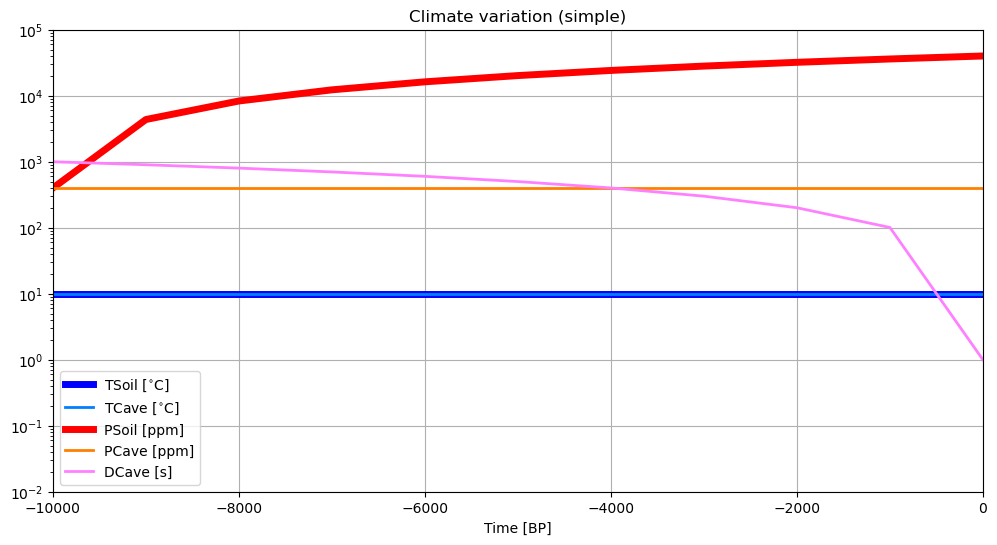

In [6]:
timeWrite = 1000
nstack = 200
data   = np.zeros(6*nstack).reshape(6,nstack)
print(data.shape)

itime  = 0
iSaved = 0
time   = timeStart
while (time <= timeEnd):
    TSoil,PSoil,TCave,PCave,DCave = libSTALAGMITE.setClimate2D(time,timeStart,timeEnd,
               TSoilmin,TSoilmax,
               PSoilmin,PSoilmax,
               TCavemin,TCavemax,
               PCavemin,PCavemax,
               DCavemin,DCavemax,rawTimeline=rawTimeline,climate=climate)
    # save time step
    if (time % timeWrite == 0):
        data[0,iSaved] = time
        data[1,iSaved] = TSoil
        data[2,iSaved] = TCave
        data[3,iSaved] = PSoil
        data[4,iSaved] = PCave
        data[5,iSaved] = DCave
        #print(itime,iSaved,time)
        iSaved = iSaved + 1
    # update time step
    time += timeStep
    itime += 1
    
print(climate,iSaved,timeStart,timeEnd)
plotClimate(iSaved,data,climate)

----
## Paleo climate driver

In [7]:
PAtmmin,PAtmmax   = 400.0,    400.0
TSoilmin,TSoilmax =  0.0,      10.0
PSoilmin,PSoilmax = 400.0,  40000.0
TCavemin,TCavemax = 10.0,      10.0
PCavemin,PCavemax = 400.0,    400.0
DCavemin,DCavemax = 1000.0,     1.0

timeStep          = 1000.
timeStart,timeEnd,rawTimeline = libSTALAGMITE.readTimeline2D(path='div/run_vostok1/',control=True)
print(rawTimeline.shape)

climate='paleo'

        timeStart,timeEnd [a]: -420000.00         0.00
(43, 2)


(6, 500)
paleo 421 -420000.0 0.0


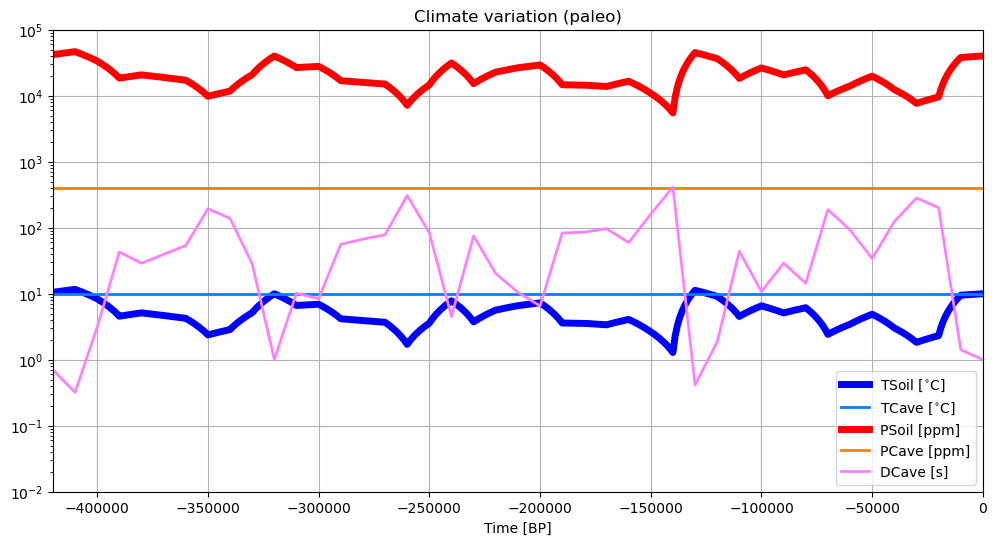

In [8]:
timeWrite = 1000
nstack = 500
data   = np.zeros(6*nstack).reshape(6,nstack)
print(data.shape)

itime  = 0
iSaved = 0
time   = timeStart
while (time <= timeEnd):
    TSoil,PSoil,TCave,PCave,DCave = libSTALAGMITE.setClimate2D(time,timeStart,timeEnd,
               TSoilmin,TSoilmax,
               PSoilmin,PSoilmax,
               TCavemin,TCavemax,
               PCavemin,PCavemax,
               DCavemin,DCavemax,rawTimeline=rawTimeline,climate=climate)
    # save time step
    if (time % timeWrite == 0):
        data[0,iSaved] = time
        data[1,iSaved] = TSoil
        data[2,iSaved] = TCave
        data[3,iSaved] = PSoil
        data[4,iSaved] = PCave
        data[5,iSaved] = DCave
        #print(itime,iSaved,time,DCave)
        iSaved = iSaved + 1
    # update time step
    time += timeStep
    itime += 1

print(climate,iSaved,timeStart,timeEnd)
plotClimate(iSaved,data,climate)

----